# Scientific Validation and Explainability

## 1. Architectural Ablation Study
To empirically justify the complexity of our proposed Multi-Model Ensemble, we conduct an Ablation Study. We systematically isolate the morphological features (U-Net) and the deep texture features (EfficientNet) and evaluate their standalone predictive power using isolated XGBoost classifiers. 

By comparing the standalone accuracies against the fused ensemble, we determine the relative contribution of physical structural data versus deep representation data in cervical cancer diagnosis.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [3]:
csv_path = r"..\processed_data\extracted_features_enhanced.csv"
df_clean = pd.read_csv(csv_path)
df_clean.fillna(0, inplace=True)

y = df_clean['True_Class']

# === FEATURE GROUPS ===
# EfficientNet CNN probability columns
cnn_cols = ['Prob_0', 'Prob_1', 'Prob_2', 'Prob_3', 'Prob_4']

# U-Net biological features (everything except CNN probs)
unet_cols = [c for c in df_clean.columns if c not in ['Image_Name', 'True_Class'] + cnn_cols]

# Morphology features (shape & size from U-Net segmentation)
morph_cols = ['Nuc_Area', 'Cyt_Area', 'Total_Area', 'NC_Ratio', 'Nuc_Perimeter',
              'Nuc_Circularity', 'Nuc_Eccentricity', 'Nucleus_Aspect', 'Nucleus_Solidity',
              'Nucleus_Extent', 'Centroid_Dist']

# Shape descriptor features (Hu Moments + Fourier)
shape_cols = ['Hu_1', 'Hu_2', 'Hu_3', 'Hu_4', 'Hu_5', 'Hu_6', 'Hu_7',
              'Fourier_1', 'Fourier_2', 'Fourier_3', 'Fourier_4', 'Fourier_5']

# Texture features (GLCM + LBP + Entropy + Chromatin)
texture_cols = ['Chromatin_Variance', 'Nucleus_Entropy',
                'GLCM_Contrast', 'GLCM_Correlation', 'GLCM_Energy', 'GLCM_Homogeneity',
                'LBP_0', 'LBP_1', 'LBP_2', 'LBP_3', 'LBP_4', 'LBP_5', 'LBP_6', 'LBP_7', 'LBP_8']

# Intensity features (pixel statistics)
intensity_cols = ['Nuc_Mean', 'Nuc_Median', 'Nuc_Std', 'Nuc_Skew', 'Nuc_Kurtosis']

# Color features
color_cols = ['RG_Ratio', 'RB_Ratio', 'GB_Ratio']

print(f"CNN Features:        {len(cnn_cols)}")
print(f"Morphology Features: {len(morph_cols)}")
print(f"Shape Features:      {len(shape_cols)}")
print(f"Texture Features:    {len(texture_cols)}")
print(f"Intensity Features:  {len(intensity_cols)}")
print(f"Color Features:      {len(color_cols)}")
print(f"All U-Net Features:  {len(unet_cols)}")
print(f"Total Features:      {len(cnn_cols) + len(unet_cols)}")

CNN Features:        5
Morphology Features: 11
Shape Features:      12
Texture Features:    15
Intensity Features:  5
Color Features:      3
All U-Net Features:  46
Total Features:      51


In [4]:
from scipy.stats import mode
import lightgbm as lgb_lib
from sklearn.ensemble import RandomForestClassifier

In [5]:
print("=" * 60)
print("   ABLATION STUDY ON CLEAN DATA")
print("=" * 60)

X_clean = df_clean.drop(columns=['Image_Name', 'True_Class'])
X_tr, X_te, y_tr, y_te = train_test_split(X_clean, y, test_size=0.2, random_state=42, stratify=y)

clean_results = {}

def test_model(features, X_train, X_test, y_train, y_test, model_type='xgb'):
    if model_type == 'xgb':
        model = xgb.XGBClassifier(objective='multi:softprob', eval_metric='mlogloss', n_jobs=1, random_state=42)
    elif model_type == 'lgbm':
        model = lgb_lib.LGBMClassifier(random_state=42, n_estimators=300, verbose=-1)
    elif model_type == 'rf':
        model = RandomForestClassifier(random_state=42, n_estimators=300)
    model.fit(X_train[features], y_train)
    return accuracy_score(y_test, model.predict(X_test[features])), model

# ==============================
# PART 1: Individual Components
# ==============================
print("\n--- PART 1: Individual Components ---")

cnn_pred = X_te[cnn_cols].idxmax(axis=1).str.replace('Prob_', '').astype(int)
clean_results['EfficientNet (CNN) Alone'] = accuracy_score(y_te, cnn_pred)
clean_results['Morphology Alone'], _ = test_model(morph_cols, X_tr, X_te, y_tr, y_te)
clean_results['Shape (Hu+Fourier) Alone'], _ = test_model(shape_cols, X_tr, X_te, y_tr, y_te)
clean_results['Texture (GLCM+LBP) Alone'], _ = test_model(texture_cols, X_tr, X_te, y_tr, y_te)
clean_results['Intensity Alone'], _ = test_model(intensity_cols, X_tr, X_te, y_tr, y_te)
clean_results['Color Ratios Alone'], _ = test_model(color_cols, X_tr, X_te, y_tr, y_te)
clean_results['U-Net (All Biology) Alone'], _ = test_model(unet_cols, X_tr, X_te, y_tr, y_te)

for name, acc in clean_results.items():
    print(f"  {name:35s}: {acc*100:.2f}%")

# ==============================
# PART 2: CNN + Each Model
# ==============================
print("\n--- PART 2: CNN + Each Model ---")

clean_results['CNN + XGBoost'], _ = test_model(cnn_cols, X_tr, X_te, y_tr, y_te, 'xgb')
clean_results['CNN + LightGBM'], _ = test_model(cnn_cols, X_tr, X_te, y_tr, y_te, 'lgbm')
clean_results['CNN + Random Forest'], _ = test_model(cnn_cols, X_tr, X_te, y_tr, y_te, 'rf')

for name in ['CNN + XGBoost', 'CNN + LightGBM', 'CNN + Random Forest']:
    print(f"  {name:35s}: {clean_results[name]*100:.2f}%")

# ==============================
# PART 3: U-Net + Each Model
# ==============================
print("\n--- PART 3: U-Net + Each Model ---")

clean_results['U-Net + XGBoost'], _ = test_model(unet_cols, X_tr, X_te, y_tr, y_te, 'xgb')
clean_results['U-Net + LightGBM'], _ = test_model(unet_cols, X_tr, X_te, y_tr, y_te, 'lgbm')
clean_results['U-Net + Random Forest'], _ = test_model(unet_cols, X_tr, X_te, y_tr, y_te, 'rf')

for name in ['U-Net + XGBoost', 'U-Net + LightGBM', 'U-Net + Random Forest']:
    print(f"  {name:35s}: {clean_results[name]*100:.2f}%")

# ==============================
# PART 4: U-Net + CNN + Super Ensemble
# ==============================
print("\n--- PART 4: U-Net + CNN + Super Ensemble ---")

all_features = list(X_clean.columns)
_, xgb_full = test_model(all_features, X_tr, X_te, y_tr, y_te, 'xgb')
_, lgb_full = test_model(all_features, X_tr, X_te, y_tr, y_te, 'lgbm')
_, rf_full = test_model(all_features, X_tr, X_te, y_tr, y_te, 'rf')

pred_x = xgb_full.predict(X_te[all_features])
pred_l = lgb_full.predict(X_te[all_features])
pred_r = rf_full.predict(X_te[all_features])

stacked = np.stack([pred_x, pred_l, pred_r], axis=1)
pred_super = mode(stacked, axis=1, keepdims=False).mode
clean_results['U-Net + CNN + Super Ensemble'] = accuracy_score(y_te, pred_super)

print(f"  {'U-Net + CNN + Super Ensemble':35s}: {clean_results['U-Net + CNN + Super Ensemble']*100:.2f}%")

print("\n" + "=" * 60)
print("Clean Data Testing Complete!")


   ABLATION STUDY ON CLEAN DATA

--- PART 1: Individual Components ---
  EfficientNet (CNN) Alone           : 98.77%
  Morphology Alone                   : 56.79%
  Shape (Hu+Fourier) Alone           : 44.57%
  Texture (GLCM+LBP) Alone           : 77.28%
  Intensity Alone                    : 62.22%
  Color Ratios Alone                 : 60.25%
  U-Net (All Biology) Alone          : 90.12%

--- PART 2: CNN + Each Model ---
  CNN + XGBoost                      : 98.89%
  CNN + LightGBM                     : 98.89%
  CNN + Random Forest                : 98.89%

--- PART 3: U-Net + Each Model ---
  U-Net + XGBoost                    : 90.12%
  U-Net + LightGBM                   : 91.48%
  U-Net + Random Forest              : 89.38%

--- PART 4: U-Net + CNN + Super Ensemble ---
  U-Net + CNN + Super Ensemble       : 98.89%

Clean Data Testing Complete!


In [6]:
print("=" * 60)
print("   ABLATION STUDY ON CORRUPTED DATA")
print("   (15% of images simulated as extremely blurry)")
print("=" * 60)

df_corr = df_clean.copy()
np.random.seed(42)
confused_indices = np.random.choice(df_corr.index, size=int(0.15 * len(df_corr)), replace=False)
for col in cnn_cols:
    df_corr.loc[confused_indices, col] = np.random.uniform(0.1, 0.9, size=len(confused_indices))

X_corr = df_corr.drop(columns=['Image_Name', 'True_Class'])
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(X_corr, y, test_size=0.2, random_state=42, stratify=y)

corr_results = {}

# ==============================
# PART 1: Individual Components
# ==============================
print("\n--- PART 1: Individual Components ---")

cnn_pred_c = X_te_c[cnn_cols].idxmax(axis=1).str.replace('Prob_', '').astype(int)
corr_results['EfficientNet (CNN) Alone'] = accuracy_score(y_te_c, cnn_pred_c)
corr_results['Morphology Alone'], _ = test_model(morph_cols, X_tr_c, X_te_c, y_tr_c, y_te_c)
corr_results['Shape (Hu+Fourier) Alone'], _ = test_model(shape_cols, X_tr_c, X_te_c, y_tr_c, y_te_c)
corr_results['Texture (GLCM+LBP) Alone'], _ = test_model(texture_cols, X_tr_c, X_te_c, y_tr_c, y_te_c)
corr_results['Intensity Alone'], _ = test_model(intensity_cols, X_tr_c, X_te_c, y_tr_c, y_te_c)
corr_results['Color Ratios Alone'], _ = test_model(color_cols, X_tr_c, X_te_c, y_tr_c, y_te_c)
corr_results['U-Net (All Biology) Alone'], _ = test_model(unet_cols, X_tr_c, X_te_c, y_tr_c, y_te_c)

for name, acc in corr_results.items():
    print(f"  {name:35s}: {acc*100:.2f}%")

# ==============================
# PART 2: CNN + Each Model
# ==============================
print("\n--- PART 2: CNN + Each Model ---")

corr_results['CNN + XGBoost'], _ = test_model(cnn_cols, X_tr_c, X_te_c, y_tr_c, y_te_c, 'xgb')
corr_results['CNN + LightGBM'], _ = test_model(cnn_cols, X_tr_c, X_te_c, y_tr_c, y_te_c, 'lgbm')
corr_results['CNN + Random Forest'], _ = test_model(cnn_cols, X_tr_c, X_te_c, y_tr_c, y_te_c, 'rf')

for name in ['CNN + XGBoost', 'CNN + LightGBM', 'CNN + Random Forest']:
    print(f"  {name:35s}: {corr_results[name]*100:.2f}%")

# ==============================
# PART 3: U-Net + Each Model
# ==============================
print("\n--- PART 3: U-Net + Each Model ---")

corr_results['U-Net + XGBoost'], _ = test_model(unet_cols, X_tr_c, X_te_c, y_tr_c, y_te_c, 'xgb')
corr_results['U-Net + LightGBM'], _ = test_model(unet_cols, X_tr_c, X_te_c, y_tr_c, y_te_c, 'lgbm')
corr_results['U-Net + Random Forest'], _ = test_model(unet_cols, X_tr_c, X_te_c, y_tr_c, y_te_c, 'rf')

for name in ['U-Net + XGBoost', 'U-Net + LightGBM', 'U-Net + Random Forest']:
    print(f"  {name:35s}: {corr_results[name]*100:.2f}%")

# ==============================
# PART 4: U-Net + CNN + Super Ensemble
# ==============================
print("\n--- PART 4: U-Net + CNN + Super Ensemble ---")

all_features = list(X_corr.columns)
_, xgb_full_c = test_model(all_features, X_tr_c, X_te_c, y_tr_c, y_te_c, 'xgb')
_, lgb_full_c = test_model(all_features, X_tr_c, X_te_c, y_tr_c, y_te_c, 'lgbm')
_, rf_full_c = test_model(all_features, X_tr_c, X_te_c, y_tr_c, y_te_c, 'rf')

pred_xc = xgb_full_c.predict(X_te_c[all_features])
pred_lc = lgb_full_c.predict(X_te_c[all_features])
pred_rc = rf_full_c.predict(X_te_c[all_features])

stacked_c = np.stack([pred_xc, pred_lc, pred_rc], axis=1)
pred_super_c = mode(stacked_c, axis=1, keepdims=False).mode
corr_results['U-Net + CNN + Super Ensemble'] = accuracy_score(y_te_c, pred_super_c)

print(f"  {'U-Net + CNN + Super Ensemble':35s}: {corr_results['U-Net + CNN + Super Ensemble']*100:.2f}%")

print("\n" + "=" * 60)
print("Corrupted Data Testing Complete!")


   ABLATION STUDY ON CORRUPTED DATA
   (15% of images simulated as extremely blurry)

--- PART 1: Individual Components ---
  EfficientNet (CNN) Alone           : 85.80%
  Morphology Alone                   : 56.79%
  Shape (Hu+Fourier) Alone           : 44.57%
  Texture (GLCM+LBP) Alone           : 77.28%
  Intensity Alone                    : 62.22%
  Color Ratios Alone                 : 60.25%
  U-Net (All Biology) Alone          : 90.12%

--- PART 2: CNN + Each Model ---
  CNN + XGBoost                      : 87.28%
  CNN + LightGBM                     : 87.28%
  CNN + Random Forest                : 87.53%

--- PART 3: U-Net + Each Model ---
  U-Net + XGBoost                    : 90.12%
  U-Net + LightGBM                   : 91.48%
  U-Net + Random Forest              : 89.38%

--- PART 4: U-Net + CNN + Super Ensemble ---
  U-Net + CNN + Super Ensemble       : 96.67%

Corrupted Data Testing Complete!


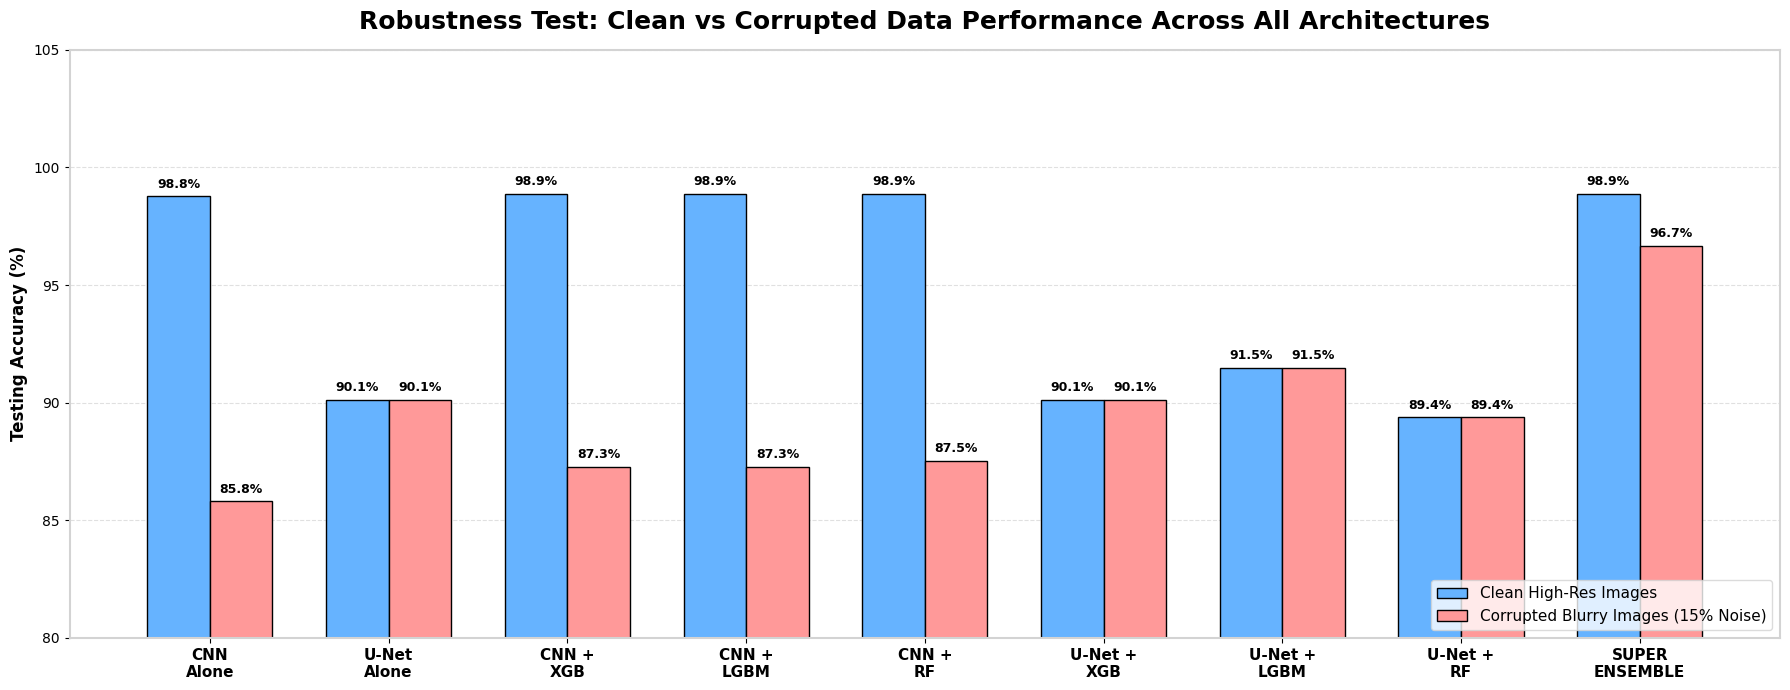

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 1. The exact 9 models we want to compare
models_to_plot = [
    'EfficientNet (CNN) Alone', 
    'U-Net (All Biology) Alone',
    'CNN + XGBoost', 
    'CNN + LightGBM', 
    'CNN + Random Forest',
    'U-Net + XGBoost', 
    'U-Net + LightGBM', 
    'U-Net + Random Forest',
    'U-Net + CNN + Super Ensemble'
]

# Shorter labels so they fit nicely on the X-axis
display_labels = [
    'CNN\nAlone', 
    'U-Net\nAlone', 
    'CNN +\nXGB', 
    'CNN +\nLGBM', 
    'CNN +\nRF',
    'U-Net +\nXGB', 
    'U-Net +\nLGBM', 
    'U-Net +\nRF', 
    'SUPER\nENSEMBLE'
]

# 2. Extract the accuracies from our results dictionaries
clean_accs = [clean_results[m] * 100 for m in models_to_plot]
corr_accs = [corr_results[m] * 100 for m in models_to_plot]

# 3. Set up the grouped bar chart layout (made wider for 9 items)
x = np.arange(len(display_labels))  
width = 0.35  

fig, ax = plt.subplots(figsize=(18, 7))

# 4. Plot the bars with the requested styling
rects1 = ax.bar(x - width/2, clean_accs, width, label='Clean High-Res Images', 
                color='#66b3ff', edgecolor='black', linewidth=1)
rects2 = ax.bar(x + width/2, corr_accs, width, label='Corrupted Blurry Images (15% Noise)', 
                color='#ff9999', edgecolor='black', linewidth=1)

# 5. Add Text, Labels, and Title
ax.set_ylabel('Testing Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Robustness Test: Clean vs Corrupted Data Performance Across All Architectures', 
             fontsize=18, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(display_labels, fontweight='bold', fontsize=11)
ax.set_ylim(80, 105) # Zooms in so the differences are easier to see!

# Legend styling
ax.legend(loc='lower right', frameon=True, edgecolor='lightgray', fancybox=True, fontsize=11)

# Grid styling
ax.yaxis.grid(True, linestyle='--', alpha=0.7, color='lightgray')
ax.set_axisbelow(True)

# 6. Function to attach the percentage text on top of each bar
def autolabel(rects):
    """Attach a text label above each bar."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 4),  # 4 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=9, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

# 7. Add a subtle border around the plot
for spine in ax.spines.values():
    spine.set_edgecolor('lightgray')
    spine.set_linewidth(1.5)

fig.tight_layout()
plt.show()


## 2. Explainable AI (XAI) via Grad-CAM
In clinical deployment, "Black Box" algorithms are widely rejected by medical professionals. To ensure diagnostic transparency, we implement Gradient-weighted Class Activation Mapping (Grad-CAM). 

By extracting the spatial gradients from the final convolutional layer of our EfficientNet model, we generate a thermal activation heatmap. This visually proves that the Neural Network is focusing on the correct biological structures (e.g., the cellular nucleus and chromatin density) rather than overfitting to background slide artifacts.

In [8]:
import torch
import torch.nn.functional as F
import cv2
from torchvision import models, transforms
from PIL import Image

In [9]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [11]:
model = models.efficientnet_b0(weights=None)
num_ftrs = model.classifier[1].in_features
model.classifier[1] = torch.nn.Linear(num_ftrs, 5) 
model.load_state_dict(torch.load(r"..\trained_models\cnn\efficientnet_sipakmed.pth", map_location=device))
print("EfficientNet Model Loaded Successfully!")
model = model.to(device)
model.eval()


C:\Users\parth\AppData\Local\Temp\ipykernel_28004\1544638385.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(r"..\trained_models\cnn\eff

EfficientNet Model Loaded Successfully!


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [12]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Hook the target layer
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)
    def save_activation(self, module, input, output):
        self.activations = output
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]
    def __call__(self, x, class_idx=None):
        # Forward pass
        outputs = self.model(x)
        
        if class_idx is None:
            class_idx = torch.argmax(outputs, dim=1).item()
            
        # Backward pass
        self.model.zero_grad()
        class_score = outputs[0, class_idx]
        class_score.backward()
        
        # Get gradients and activations
        gradients = self.gradients.cpu().data.numpy()[0]
        activations = self.activations.cpu().data.numpy()[0]
        
        # Calculate weights (global average pooling of gradients)
        weights = np.mean(gradients, axis=(1, 2))
        
        # Apply weights to activations
        cam = np.zeros(activations.shape[1:], dtype=np.float32)
        for i, w in enumerate(weights):
            cam += w * activations[i]
            
        # Apply ReLU to only keep positive influences
        cam = np.maximum(cam, 0)
        
        # Normalize between 0 and 1
        cam = cv2.resize(cam, (x.shape[2], x.shape[3]))
        cam = cam - np.min(cam)
        cam = cam / np.max(cam)
        
        return cam, class_idx

In [13]:
target_layer = model.features[-1]
grad_cam = GradCAM(model, target_layer)

In [14]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [15]:
def visualize_gradcam(image_path):
    # Load and prep image
    img = Image.open(image_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(device)
    
    # Run Grad-CAM
    cam, pred_class = grad_cam(input_tensor)
    
    # Overlay heatmap on original image
    img_cv = cv2.imread(image_path)
    img_cv = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
    img_cv = cv2.resize(img_cv, (224, 224))
    
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    
    overlay = cv2.addWeighted(img_cv, 0.6, heatmap, 0.4, 0)
    
    # Plotting
    classes = ['Dyskeratotic', 'Koilocytotic', 'Metaplastic', 'Parabasal', 'Superficial']
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(img_cv)
    axes[0].set_title("Original Image")
    axes[0].axis('off')
    
    axes[1].imshow(cam, cmap='jet')
    axes[1].set_title("Grad-CAM Heatmap")
    axes[1].axis('off')
    
    axes[2].imshow(overlay)
    axes[2].set_title(f"Overlay (Predicted: {classes[pred_class]})")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

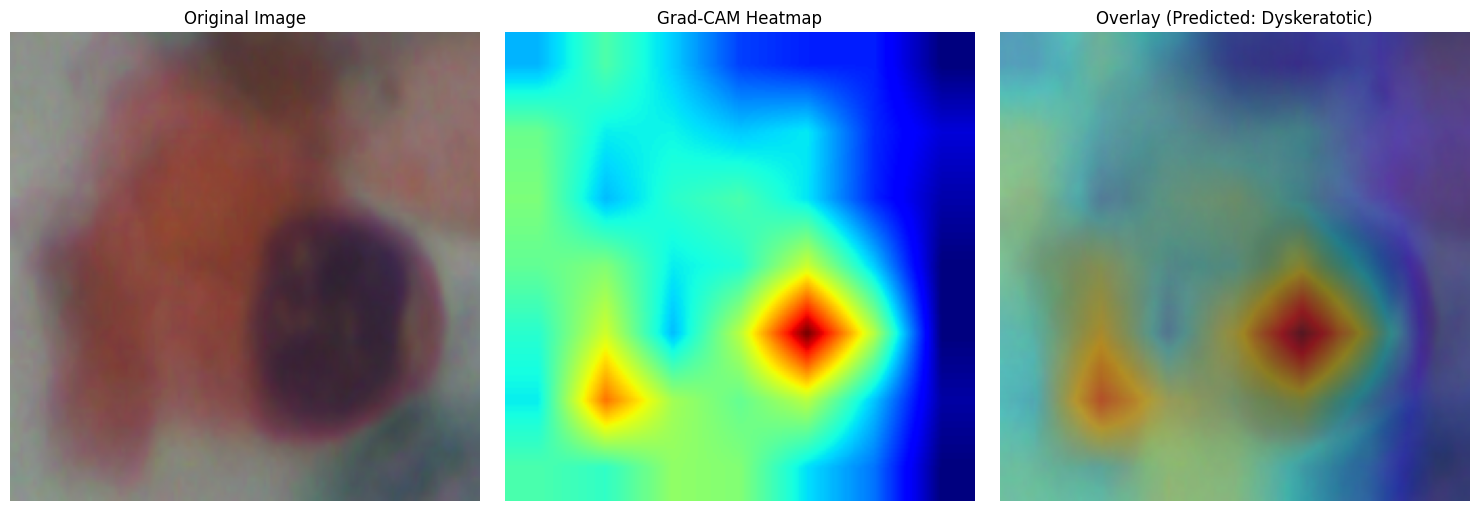

In [20]:
img_path = r"E:\SIPaKMeD\Dataset\im_Dyskeratotic\im_Dyskeratotic\CROPPED\009_08.bmp"
visualize_gradcam(img_path)